In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.linalg import expm
from datetime import datetime
import time
import scipy.sparse as sp

In [56]:
def ETDFDM_AC(N,h = 1/4):
    time_start = time.time()
    debug = False
    ##FDM quantities
    ##Discretise space:
    x = np.linspace(-1,1,N)
    dx = x[1] - x[0]
    ##set initial conditions
    u = (0.53*x + 0.47*np.sin(-1.5*np.pi*x))
    u[0] = -1
    u[-1] = 1
    ## Differentiation matrix plus identity:
    D = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()/(dx**2)
    I = np.eye(N)
    ##Linear operator L:
    L = 0.01*D
    L[0,:] = L[-1,:] = 0
    L[0,0] = L[-1,-1] = 1

    ##ETD quantities
    M = 64

    r = 15 * np.exp(1j * 2*np.pi * (np.arange(1, M+1) - 0.5) / M)

    A = h * L
    A[0,0] = np.log(1)
    A[-1,-1] = np.log(1)
    E = expm(A)
    E2 = expm(A / 2)

    I = np.eye(N)
    Z = np.zeros((N, N))

    f1 = Z.copy()
    f2 = Z.copy()
    f3 = Z.copy()
    Q  = Z.copy()

    for j in range(M):
        z = r[j]
        zIA = np.linalg.inv(z * I - A)

        Q  = Q + h * zIA * (np.exp(z/2) - 1)
        f1 = f1 + h * zIA * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
        f2 = f2 + h * zIA * (2 + z + np.exp(z)*(z - 2)) / z**2
        f3 = f3 + h * zIA * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2

    Q  = np.real(Q)/M
    f1 = np.real(f1)/M
    f2 = np.real(f2)/M
    f3 = np.real(f3)/M

    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    tmax = 70
    nmax = int(np.ceil(tmax / h))
    nplt = max(1, int(np.floor((tmax / 20) / h)))

    for n in range(1, nmax + 1):
        #print("n = ", n)
        t = n * h
        
        Nu = u-u**3
        if debug:
            print("BC equals: at u", u[0], u[-1])
        
        Nu[-1] = Nu[0] = 0
        
        a  = E2 @ u + Q @ Nu
        Na = a-a**3
        
        Na[-1] = Na[0] = 0
        
        
        
        if debug:
            print("BC equals: at a", a[0], a[-1])
            
        b  = E2 @ u + Q @ Na
        Nb = b-b**3

        Nb[-1] = Nb[0] = 0

        c  = E2 @ a + Q @ (2*Nb - Nu)
        Nc = c-c**3

        Nc[-1] = Nc[0] = 0
        
        u = E @ u + f1 @ Nu + 2*f2 @ (Na + Nb) + f3 @ Nc

        u[0] = -1
        u[-1] = 1
        
        
        if n % nplt == 0:
            #print("Saving at t = ", t)
            
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)
            
    time_end = time.time()
    time_elapsed = time_end - time_start
    print(f"ETD_AC execution time: {time_elapsed} seconds")

    return [x, tt, uu, time_elapsed]
        

In [57]:
def ETD_AC(N,h = 1/16):
    time_start = time.time()
    
    
    # Parameters
    #N = 2**6
    D, x = cheb(N)
    #print(x)
    x = x[1:N]                 # MATLAB: x = x(2:N)
    #print(x)
    
    # Initial condition
    w = 0.53*x + 0.47*np.sin(-1.5*np.pi*x) - x
    u = np.concatenate(([1], w + x, [-1]))

    # Precompute ETDRK4 quantities
    #h = 1/4
    M = 32

    r = 15 * np.exp(1j * np.pi * (np.arange(1, M+1) - 0.5) / M)

    L = D @ D
    L = 0.01 * L[1:N, 1:N]

    A = h * L
    E = expm(A)
    E2 = expm(A / 2)

    I = np.eye(N-1)
    Z = np.zeros((N-1, N-1))

    f1 = Z.copy()
    f2 = Z.copy()
    f3 = Z.copy()
    Q  = Z.copy()

    for j in range(M):
        z = r[j]
        zIA = np.linalg.inv(z * I - A)

        Q  = Q + h * zIA * (np.exp(z/2) - 1)
        f1 = f1 + h * zIA * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
        f2 = f2 + h * zIA * (2 + z + np.exp(z)*(z - 2)) / z**2
        f3 = f3 + h * zIA * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2

    Q  = np.real(Q)/M
    f1 = np.real(f1)/M
    f2 = np.real(f2)/M
    f3 = np.real(f3)/M

    # Main time-stepping loop
    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    tmax = 70
    nmax = round(tmax / h)
    nplt = max(1, int(np.floor((tmax / 20) / h)))

    for n in range(1, nmax + 1):
        #print("n = ", n)
        t = n * h

        Nu = (w + x) - (w + x)**3
        a  = E2 @ w + Q @ Nu
        Na = a + x - (a + x)**3

        b  = E2 @ w + Q @ Na
        Nb = b + x - (b + x)**3

        c  = E2 @ a + Q @ (2*Nb - Nu)
        Nc = c + x - (c + x)**3

        w = E @ w + f1 @ Nu + 2*f2 @ (Na + Nb) + f3 @ Nc

        if n % nplt == 0:
            #print("Saving at t = ", t)
            u = np.concatenate(([1], w + x, [-1]))
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)
            
    time_end = time.time()
    time_elapsed = time_end - time_start
    print(f"ETD_AC execution time: {time_elapsed} seconds")
            
    return [x, tt, uu, time_elapsed]

In [58]:
def EM_AC(N, mu):
    time_start = time.time()

    tmax = 70
    d = N
    dx = 2/(d-1)
    dt = mu * (dx**2)
    

    
    nmax = int(np.ceil(tmax / dt))
    # dt = tmax / nmax
    
    nplt = int(np.ceil((tmax / 70) / dt))
    # print(dt,nmax,nplt)
    # print(dt,nmax,nplt)
    
    x = np.linspace(-1,1,d)
    #print(x)
    #t = np.arange(tmax+1)*dt
    ##initial conditions
    u = 0.53*x + 0.47*np.sin(-1.5*np.pi*x)
    u[0] = -1
    u[-1] = 1
    #print(u)
    
    print(dt,d,dx)
    uu = u.copy()
    #print(uu)
    t = np.array([0.0])
    
    for n in range(nmax+1):
        unew = u.copy()
        unew[1:-1] = u[1:-1] + mu*(0.01*(u[2:] - 2*u[1:-1] + u[:-2])) + (dt)*(u[1:-1] - u[1:-1]**3)
        
            
            
        
        u = unew.copy()
        if n % nplt == 0:
            #print(f"saving at t: {n*dt}")
            uu = np.vstack((uu, u))
            t = np.append(t, n * dt)

    time_end = time.time()
    time_elapsed = time_end - time_start
    print(f"EM_AC execution time: {time_elapsed} seconds")

    return [x, t, uu, time_elapsed]


In [59]:

# Exponents: 5, 5.5, ..., 10
k_vals = np.arange(5, 10.0 + 0.5, 0.5)

# Point sizes (rounded to nearest int because N must be an integer)
N_vals = np.rint(2**k_vals).astype(int)
N_vals = np.unique(N_vals)  # safety in case rounding creates duplicates

times = []
for N in N_vals:
    print(f"Running ETDFDM_AC with N={N} ...")
    _, _, _, t_elapsed = ETDFDM_AC(N)
    times.append(t_elapsed)

times = np.array(times)



Running ETDFDM_AC with N=32 ...
ETD_AC execution time: 0.00865030288696289 seconds
Running ETDFDM_AC with N=45 ...
ETD_AC execution time: 0.03815746307373047 seconds
Running ETDFDM_AC with N=64 ...
ETD_AC execution time: 0.031069040298461914 seconds
Running ETDFDM_AC with N=91 ...
ETD_AC execution time: 0.03533649444580078 seconds
Running ETDFDM_AC with N=128 ...
ETD_AC execution time: 0.1503455638885498 seconds
Running ETDFDM_AC with N=181 ...
ETD_AC execution time: 0.2784767150878906 seconds
Running ETDFDM_AC with N=256 ...
ETD_AC execution time: 0.7530138492584229 seconds
Running ETDFDM_AC with N=362 ...
ETD_AC execution time: 1.6199893951416016 seconds
Running ETDFDM_AC with N=512 ...
ETD_AC execution time: 2.6091387271881104 seconds
Running ETDFDM_AC with N=724 ...
ETD_AC execution time: 4.663830757141113 seconds
Running ETDFDM_AC with N=1024 ...
ETD_AC execution time: 9.432329177856445 seconds


Power-law fit: t(N) ≈ 8.7476e-06 * N^2.0120


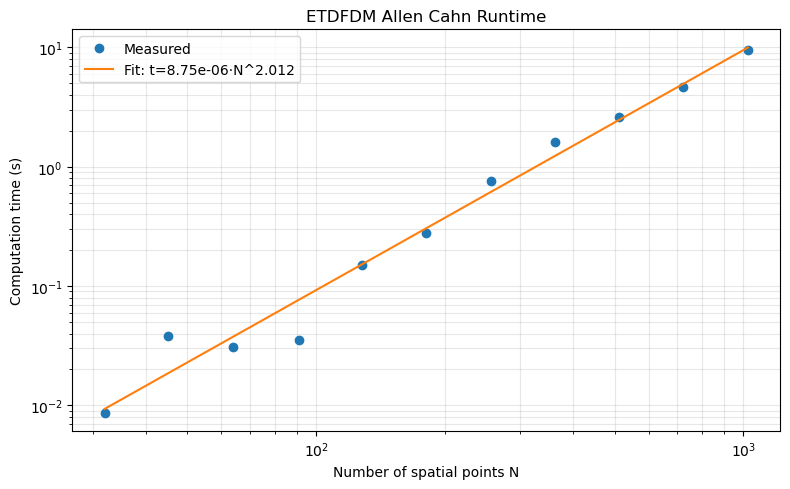

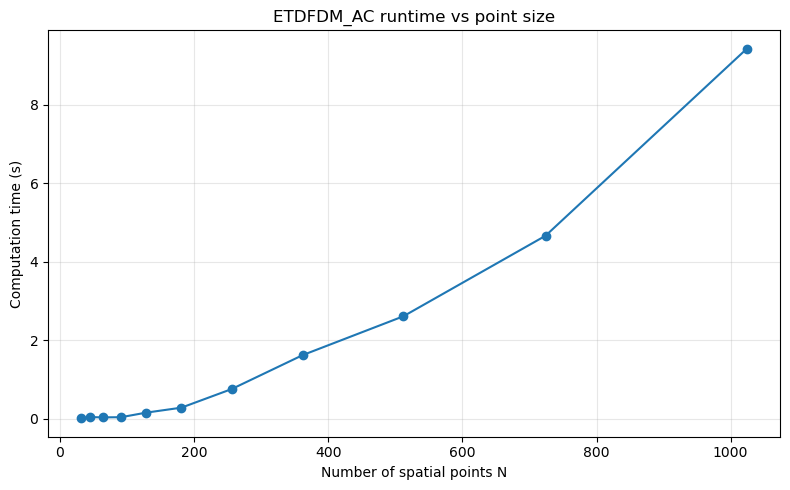

In [60]:

# Power-law fit: t = C * N^alpha
logN = np.log(N_vals)
logt = np.log(times)

alpha, logC = np.polyfit(logN, logt, 1)
C = np.exp(logC)
t_fit = C * (N_vals ** alpha)


print(f"Power-law fit: t(N) ≈ {C:.4e} * N^{alpha:.4f}")


plt.figure(figsize=(8, 5))
plt.loglog(N_vals, times, 'o', label='Measured')
plt.loglog(N_vals, t_fit, '-', label=f'Fit: t={C:.2e}·N^{alpha:.3f}')
plt.xlabel("Number of spatial points N")
plt.ylabel("Computation time (s)")
plt.title("ETDFDM Allen Cahn Runtime")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(N_vals, times, marker='o')
plt.xlabel("Number of spatial points N")
plt.ylabel("Computation time (s)")
plt.title("ETDFDM_AC runtime vs point size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [93]:
def EM_AC_matrix(N, mu=30, tmax=5.0):
    """Forward Euler using dense differentiation matrix (like ETDFDM)."""
    t0 = time.perf_counter()
    
    # Setup
    dx = 2/(N-1)
    dt = mu * dx*dx
    nmax = int(np.ceil(tmax / dt))
    
    x = np.linspace(-1, 1, N)
    u = 0.53*x + 0.47*np.sin(-1.5*np.pi*x)
    u[0], u[-1] = -1, 1
    
    # Dense differentiation matrix (Laplacian)
    D = sp.diags([1, -2, 1], [-1, 0, 1], shape=(N, N)).toarray() / (dx**2)
    
    # Time-stepping
    for _ in range(nmax):
        u = u + dt*(0.01*(D @ u) + (u - u**3))
        u[0], u[-1] = -1, 1
    
    return time.perf_counter() - t0

# Benchmark matrix-based FE
times_fe_matrix = []
for N in N_vals:
    print(f"Running EM_AC_matrix with N={N} ...")
    t_elapsed = EM_AC_matrix(N, mu=0.4, tmax=5.0)
    times_fe_matrix.append(t_elapsed)
    print(f"  Time: {t_elapsed:.4f} s")

times_fe_matrix = np.array(times_fe_matrix)

# Power-law fit for matrix-based FE
alpha_fe_mat, logC_fe_mat = np.polyfit(np.log(N_vals), np.log(times_fe_matrix), 1)
C_fe_mat = np.exp(logC_fe_mat)
fit_fe_mat = C_fe_mat * (N_vals ** alpha_fe_mat)

print(f"\nForward Euler (matrix) fit: t ≈ {C_fe_mat:.3e} * N^{alpha_fe_mat:.3f}")



Running EM_AC_matrix with N=32 ...
  Time: 0.0101 s
Running EM_AC_matrix with N=45 ...
  Time: 0.0211 s
Running EM_AC_matrix with N=64 ...
  Time: 0.0438 s
Running EM_AC_matrix with N=91 ...
  Time: 0.1033 s
Running EM_AC_matrix with N=128 ...
  Time: 1.0845 s
Running EM_AC_matrix with N=181 ...
  Time: 3.3834 s
Running EM_AC_matrix with N=256 ...
  Time: 10.4378 s
Running EM_AC_matrix with N=362 ...
  Time: 22.3502 s
Running EM_AC_matrix with N=512 ...
  Time: 47.4782 s
Running EM_AC_matrix with N=724 ...
  Time: 106.5865 s
Running EM_AC_matrix with N=1024 ...
  Time: 310.0753 s

Forward Euler (matrix) fit: t ≈ 1.562e-07 * N^3.140


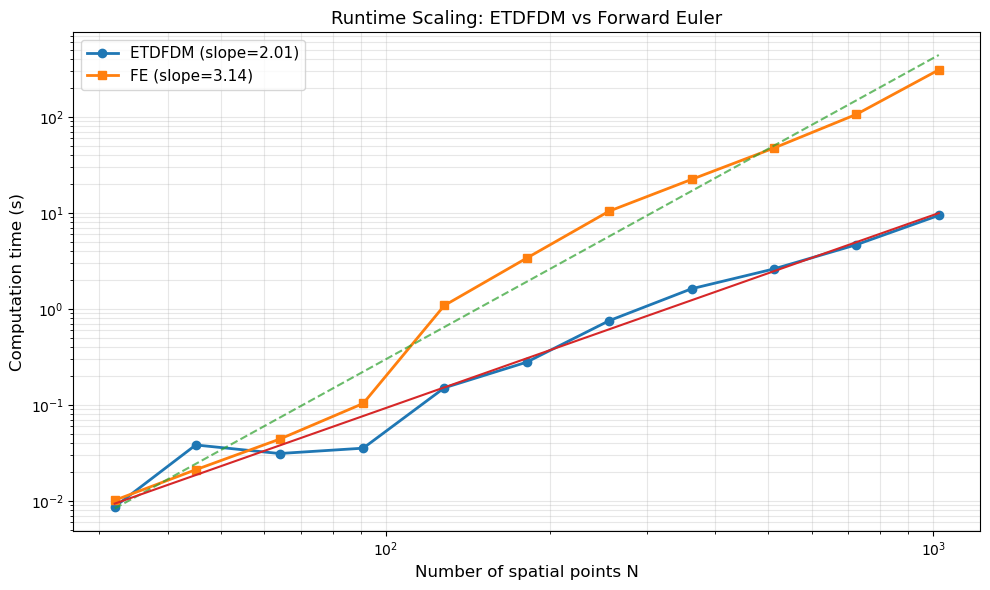

In [96]:
# Compare all three: ETDFDM, old array FE, matrix FE
plt.figure(figsize=(10, 6))
plt.loglog(N_vals, times, 'o-', linewidth=2, label=f'ETDFDM (slope={alpha:.2f})')
plt.loglog(N_vals, times_fe_matrix, 's-', linewidth=2, label=f'FE (slope={alpha_fe_mat:.2f})')
plt.loglog(N_vals, fit_fe_mat, '--', alpha=0.7)
plt.loglog(N_vals, t_fit, '-')
plt.xlabel("Number of spatial points N", fontsize=12)
plt.ylabel("Computation time (s)", fontsize=12)
plt.title("Runtime Scaling: ETDFDM vs Forward Euler", fontsize=13)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Exact same ETDFDM equation, just changing so that it finished on the fast manifold instead of the slow manifold

In [128]:
def ETDFDM_AC(N,h = 1/4):
    time_start = time.time()
    debug = False
    ##FDM quantities
    ##Discretise space:
    x = np.linspace(-1,1,N)
    dx = x[1] - x[0]
    ##set initial conditions
    u = (0.53*x + 0.47*np.sin(-1.5*np.pi*x))
    u[0] = -1
    u[-1] = 1
    ## Differentiation matrix plus identity:
    D = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()/(dx**2)
    I = np.eye(N)
    ##Linear operator L:
    L = 0.01*D
    L[0,:] = L[-1,:] = 0
    L[0,0] = L[-1,-1] = 1

    ##ETD quantities
    M = 64

    r = 15 * np.exp(1j * 2*np.pi * (np.arange(1, M+1) - 0.5) / M)

    A = h * L
    A[0,0] = np.log(1)
    A[-1,-1] = np.log(1)
    E = expm(A)
    E2 = expm(A / 2)

    I = np.eye(N)
    Z = np.zeros((N, N))

    f1 = Z.copy()
    f2 = Z.copy()
    f3 = Z.copy()
    Q  = Z.copy()

    for j in range(M):
        z = r[j]
        zIA = np.linalg.inv(z * I - A)

        Q  = Q + h * zIA * (np.exp(z/2) - 1)
        f1 = f1 + h * zIA * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
        f2 = f2 + h * zIA * (2 + z + np.exp(z)*(z - 2)) / z**2
        f3 = f3 + h * zIA * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2

    Q  = np.real(Q)/M
    f1 = np.real(f1)/M
    f2 = np.real(f2)/M
    f3 = np.real(f3)/M

    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    tmax = 1
    nmax = int(np.ceil(tmax / h))
    nplt = max(1, int(np.floor((tmax / 20) / h)))

    for n in range(1, nmax + 1):
        #print("n = ", n)
        t = n * h
        
        Nu = u-u**3
        if debug:
            print("BC equals: at u", u[0], u[-1])
        
        Nu[-1] = Nu[0] = 0
        
        a  = E2 @ u + Q @ Nu
        Na = a-a**3
        
        Na[-1] = Na[0] = 0
        
        
        
        if debug:
            print("BC equals: at a", a[0], a[-1])
            
        b  = E2 @ u + Q @ Na
        Nb = b-b**3

        Nb[-1] = Nb[0] = 0

        c  = E2 @ a + Q @ (2*Nb - Nu)
        Nc = c-c**3

        Nc[-1] = Nc[0] = 0
        
        u = E @ u + f1 @ Nu + 2*f2 @ (Na + Nb) + f3 @ Nc

        u[0] = -1
        u[-1] = 1
        
        
        if n % nplt == 0:
            #print("Saving at t = ", t)
            
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)
            
    time_end = time.time()
    time_elapsed = time_end - time_start
    print(f"ETD_AC execution time: {time_elapsed} seconds")

    return [x, tt, uu, time_elapsed]
        

In [129]:

# Step 1: compute high-resolution reference solution
N_ref = 4096
print(f"Computing reference solution at N={N_ref}...")
x_ref, tt_ref, uu_ref, _ = ETDFDM_AC(N_ref)
u_ref_final = uu_ref[:, -1]  # solution at final time
print("Reference solution computed.")

Computing reference solution at N=4096...
ETD_AC execution time: 184.06276202201843 seconds
Reference solution computed.


In [130]:

# Step 2: benchmark both methods, recording error and time
errors_etd = []
errors_fe  = []
times_etd  = []
times_fe   = []

tmax = 1.0

for N in N_vals:
    print(f"\nN = {N}")
    
    # --- ETDFDM ---
    x_n, _, uu_n, t_etd = ETDFDM_AC(N)
    u_etd_final = uu_n[:, -1]
    u_ref_interp = np.interp(x_n, x_ref, u_ref_final)
    
    diff_etd = u_etd_final - u_ref_interp
    err_etd = np.linalg.norm(diff_etd) / np.linalg.norm(u_ref_interp)
    errors_etd.append(err_etd)
    times_etd.append(t_etd)

    # --- Forward Euler ---
    t0 = time.perf_counter()
    dx = 2/(N-1)
    mu = 30
    dt = mu * dx**2
    nmax_fe = int(np.ceil(tmax / dt))
    dt = tmax / nmax_fe
    
    x_fe = np.linspace(-1, 1, N)
    u_fe = 0.53*x_fe + 0.47*np.sin(-1.5*np.pi*x_fe)
    u_fe[0], u_fe[-1] = -1, 1
    D = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray() / dx**2
    for _ in range(nmax_fe):
        u_fe = u_fe + dt*(0.01*(D @ u_fe) + (u_fe - u_fe**3))
        u_fe[0], u_fe[-1] = -1, 1
    t_fe = time.perf_counter() - t0
    print(f"  Forward Euler (matrix) time: {t_fe:.4f} s")
    
    u_ref_interp_fe = np.interp(x_fe, x_ref, u_ref_final)
    diff_fe = u_fe - u_ref_interp_fe
    err_fe = np.linalg.norm(diff_fe) / np.linalg.norm(u_ref_interp_fe)
    errors_fe.append(err_fe)
    times_fe.append(t_fe)
    
    print(f"  ETD: t={t_etd:.3f}s, rel_err={err_etd:.2e} | FE: t={t_fe:.3f}s, rel_err={err_fe:.2e}")

errors_etd = np.array(errors_etd)
errors_fe  = np.array(errors_fe)
times_etd  = np.array(times_etd)
times_fe   = np.array(times_fe)



N = 32
ETD_AC execution time: 0.004777193069458008 seconds
  Forward Euler (matrix) time: 0.0007 s
  ETD: t=0.005s, rel_err=2.36e-03 | FE: t=0.001s, rel_err=5.57e-03

N = 45
ETD_AC execution time: 0.025310754776000977 seconds
  Forward Euler (matrix) time: 0.0004 s
  ETD: t=0.025s, rel_err=1.19e-03 | FE: t=0.000s, rel_err=2.89e-03

N = 64
ETD_AC execution time: 0.023546218872070312 seconds
  Forward Euler (matrix) time: 0.0005 s
  ETD: t=0.024s, rel_err=5.83e-04 | FE: t=0.001s, rel_err=1.44e-03

N = 91
ETD_AC execution time: 0.03575396537780762 seconds
  Forward Euler (matrix) time: 0.0007 s
  ETD: t=0.036s, rel_err=2.87e-04 | FE: t=0.001s, rel_err=7.18e-04

N = 128
ETD_AC execution time: 0.0789794921875 seconds
  Forward Euler (matrix) time: 0.0045 s
  ETD: t=0.079s, rel_err=1.45e-04 | FE: t=0.004s, rel_err=3.64e-04

N = 181
ETD_AC execution time: 0.1162261962890625 seconds
  Forward Euler (matrix) time: 0.0119 s
  ETD: t=0.116s, rel_err=7.26e-05 | FE: t=0.012s, rel_err=1.84e-04

N =

In [106]:
##difference between etd and fe final solutions
diff_final = u_etd_final - u_fe

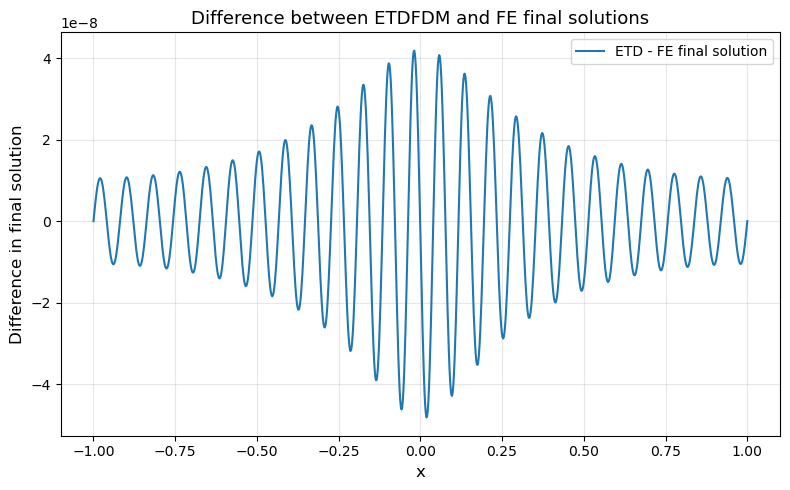

In [132]:
plt.figure(figsize=(8, 5))
plt.plot(x_fe, diff_final, label='ETD - FE final solution')
plt.xlabel("x", fontsize=12)
plt.ylabel("Difference in final solution", fontsize=12)
plt.title("Difference between ETDFDM and FE final solutions", fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

ETD_AC execution time: 0.736943244934082 seconds
0.0018454440599769317 256 0.00784313725490196
EM_AC execution time: 0.3066093921661377 seconds


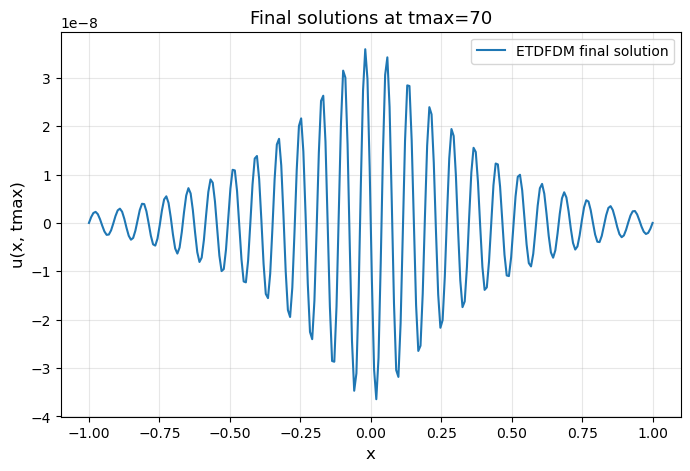

In [114]:
x1,t1,u1,time1 = ETDFDM_AC(N=2**8, h=1/4)
x2,t2,u2,time2 = EM_AC(N=2**8, mu=30)

plt.figure(figsize=(8, 5))
plt.plot(x1, u1[:, -1]- u2[-1, :], label='ETDFDM final solution')
plt.xlabel("x", fontsize=12)
plt.ylabel("u(x, tmax)", fontsize=12)
plt.title("Final solutions at tmax=70", fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

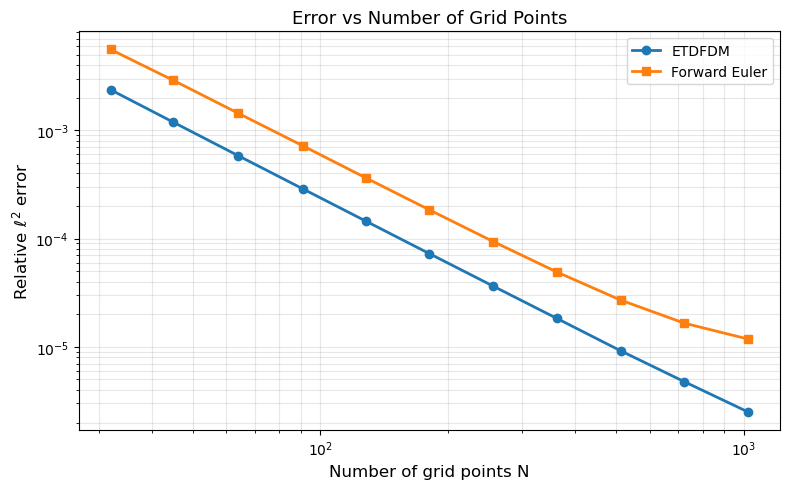

In [133]:
plt.figure(figsize=(8, 5))
plt.loglog(N_vals, errors_etd, 'o-', linewidth=2, label='ETDFDM')
plt.loglog(N_vals, errors_fe, 's-', linewidth=2, label='Forward Euler')

plt.xlabel("Number of grid points N", fontsize=12)
plt.ylabel(r"Relative $\ell^2$ error", fontsize=12)
plt.title("Error vs Number of Grid Points", fontsize=13)
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
# Step 3: accuracy vs time plot
plt.figure(figsize=(8, 5))
plt.loglog(times_etd, errors_etd, 'o-', label='ETDFDM')
plt.loglog(times_fe,  errors_fe,  's-', label='Forward Euler (matrix)')
plt.xlabel("Computation time (s)", fontsize=12)
plt.ylabel(r"$L^2$ error vs reference", fontsize=12)
plt.title("Accuracy vs Computational Time", fontsize=13)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

4096

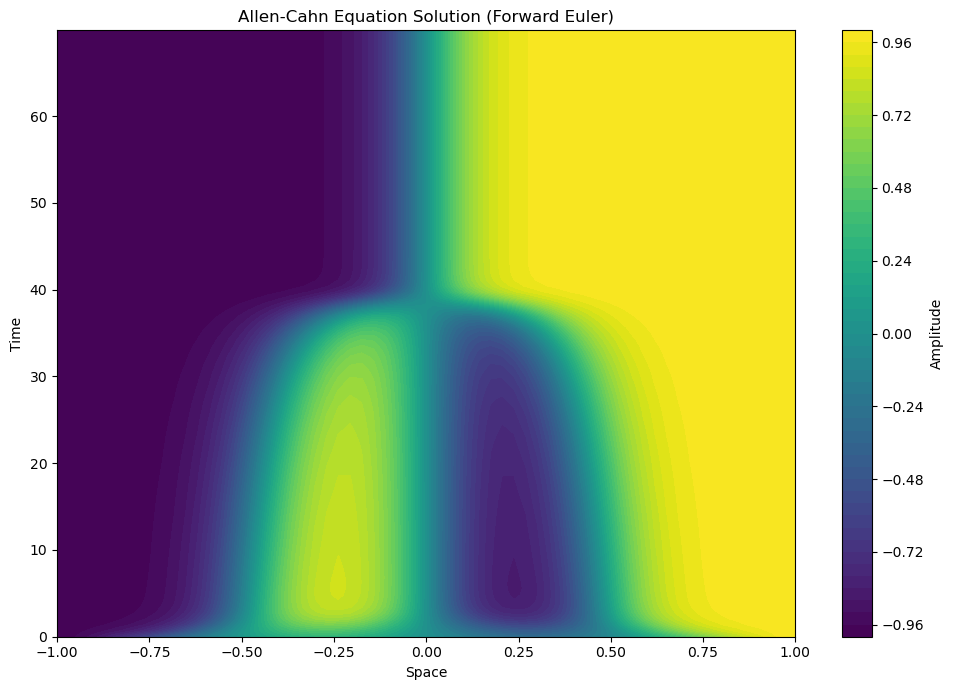

In [89]:
# Compute Forward Euler solution for visualization
N_plot = 64
tmax = 70.0
dx = 2/(N_plot-1)
mu = 40
dt = mu * dx**2
nmax = int(np.ceil(tmax / dt))
dt = tmax / nmax

x_plot = np.linspace(-1, 1, N_plot)
u_plot = 0.53*x_plot + 0.47*np.sin(-1.5*np.pi*x_plot)
u_plot[0], u_plot[-1] = -1, 1

D = sp.diags([1,-2,1],[-1,0,1],shape=(N_plot,N_plot)).toarray() / dx**2

uu_plot = u_plot.reshape(-1, 1)
tt_plot = np.array([0.0])

nplt = max(1, nmax // 100)  # Save ~100 time steps

for n in range(1, nmax + 1):
    u_plot = u_plot + dt*(0.01*(D @ u_plot) + (u_plot - u_plot**3))
    u_plot[0], u_plot[-1] = -1, 1
    
    if n % nplt == 0:
        uu_plot = np.hstack((uu_plot, u_plot.reshape(-1, 1)))
        tt_plot = np.append(tt_plot, n * dt)

# Contour plot
fig, ax = plt.subplots(figsize=(10, 7))
X, T = np.meshgrid(x_plot, tt_plot, indexing='ij')
contour = ax.contourf(X, T, uu_plot, levels=50, cmap=cm.viridis)
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Amplitude')
ax.set_xlabel('Space')
ax.set_ylabel('Time')
ax.set_title('Allen-Cahn Equation Solution (Forward Euler)')
plt.tight_layout()
plt.show()